# Grouping

## Learning Objective

By the end of this lesson, students will be able to:

Understand and apply the Split-Apply-Combine strategy to analyze grouped data.
Use groupby() to split a pandas.DataFrame by one or more columns.
Calculate summary statistics for groups in a pandas.DataFrame.
Use method chaining for readable data analysis.
Explain how groupby() handles NA values and choose between count() and size() to count observations in each group.

In [1]:
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Summary Statistics

It is easy to get summary statistics for each column in a pandas.DataFrame by using methods such as:

- sum(): sum values in each column,
- count(): count non-NA values in each column,
- size(): count the number of values in a column (including NA values),
- min() and max(): get the minimum and maximum value in each column,
- mean() and median(): get the mean and median value in each column,
- std() and var(): get the standard deviation and variance in each column.

In [2]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [3]:
# Get minimum value in each column with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

## Grouping
df.groupby(columns_to_group_by).summary_method()

In [5]:
penguins['flipper_length_mm'].mean()

200.91520467836258

In [6]:
penguins.groupby('species')['flipper_length_mm']

In [7]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [8]:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [9]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

In [10]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

11

In [11]:
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

In [12]:
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

In [13]:
penguins.groupby(['island','year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [14]:
penguins.groupby(['island','year']).size()

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

<div class="alert alert-block alert-info">
    <b>Checkin:</b>
</div>

Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

<div class="alert alert-block alert-success">
    <b>Check-in:</b>
</div>

1. `Dataframe` showing the amount of NA in each column containing attritubtes regarding the grouped by conditon, `island` and `year`.
2. The other returns just the species amount of NA.

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

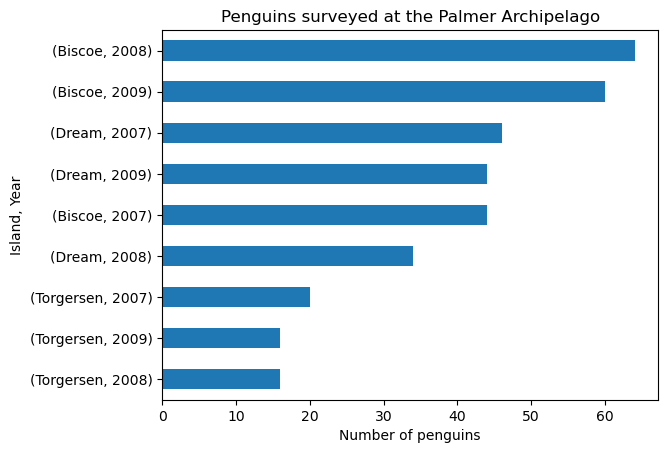

In [16]:
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

<div class="alert alert-block alert-info">
    <b>Check-in:</b>
</div>

- Use the max() method to calculate the maximum value of a penguin’s body mass by year and species.
- Use (1) to display the highest body masses per year and species as a bar plot in descending order.

<div class="alert alert-block alert-success">
    <b>Check-in:</b>
</div>


In [26]:
pbody_group = penguins.groupby('species')['body_mass_g'].max()
pbody_group

species
Adelie       4775.0
Chinstrap    4800.0
Gentoo       6300.0
Name: body_mass_g, dtype: float64

<Axes: xlabel='species'>

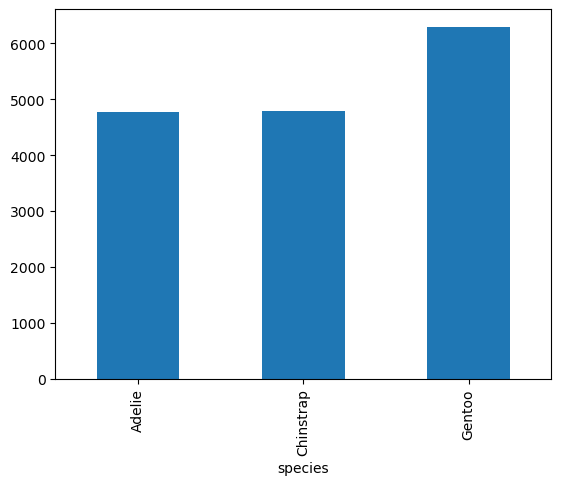

In [27]:
pbody_group.plot(kind='bar')